In [1]:
# ==============================
# Week 11 : IMDB LSTM + All Models Comparison
# MLP+GAP, Conv1D, SimpleRNN, LSTM, GRU
# ==============================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import Callback

tf.random.set_seed(42)
np.random.seed(42)

VOCAB_SIZE = 10000
MAX_LEN = 200
NUM_SAMPLES = 10000
EMBED_DIM = 128
EPOCHS = 5
BATCH = 128

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
X_train, y_train = X_train[:NUM_SAMPLES], y_train[:NUM_SAMPLES]
X_train = pad_sequences(X_train, maxlen=MAX_LEN)
X_test = pad_sequences(X_test, maxlen=MAX_LEN)

In [2]:
class LivePlot(Callback):
    def __init__(self, title=''):
        self.title = title
    def on_train_begin(self, logs=None):
        self.h = {k: [] for k in ['loss','val_loss','accuracy','val_accuracy']}
    def on_epoch_end(self, epoch, logs=None):
        for k in self.h: self.h[k].append(logs[k])
        ep = range(1, epoch + 2)
        clear_output(wait=True)
        fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
        a1.plot(ep, self.h['loss'], 'r-o', label='Train'); a1.plot(ep, self.h['val_loss'], 'b-o', label='Val')
        a1.set(title=f'{self.title} — Loss', xlabel='Epoch', ylabel='Loss'); a1.legend(); a1.grid(True, alpha=.3)
        a2.plot(ep, self.h['accuracy'], 'r-o', label='Train'); a2.plot(ep, self.h['val_accuracy'], 'b-o', label='Val')
        a2.set(title=f'{self.title} — Accuracy', xlabel='Epoch', ylabel='Accuracy'); a2.legend(); a2.grid(True, alpha=.3)
        fig.tight_layout(); display(fig); plt.close(fig)

In [3]:
# --- Model Definitions ---
def mlp_gap():
    return [tf.keras.layers.GlobalAveragePooling1D(),
            tf.keras.layers.Dense(16, activation='relu')]

def conv1d():
    return [tf.keras.layers.Conv1D(64, 5, activation='relu'),
            tf.keras.layers.GlobalMaxPooling1D(),
            tf.keras.layers.Dense(16, activation='relu')]

def simple_rnn():
    return [tf.keras.layers.SimpleRNN(64),
            tf.keras.layers.Dense(16, activation='relu')]

def lstm():
    return [tf.keras.layers.LSTM(64),
            tf.keras.layers.Dense(16, activation='relu')]

def gru():
    return [tf.keras.layers.GRU(64),
            tf.keras.layers.Dense(16, activation='relu')]

models = {
    'MLP+GAP':   mlp_gap,
    'Conv1D':    conv1d,
    'SimpleRNN': simple_rnn,
    'GRU':       gru,
    'LSTM':      lstm,
}

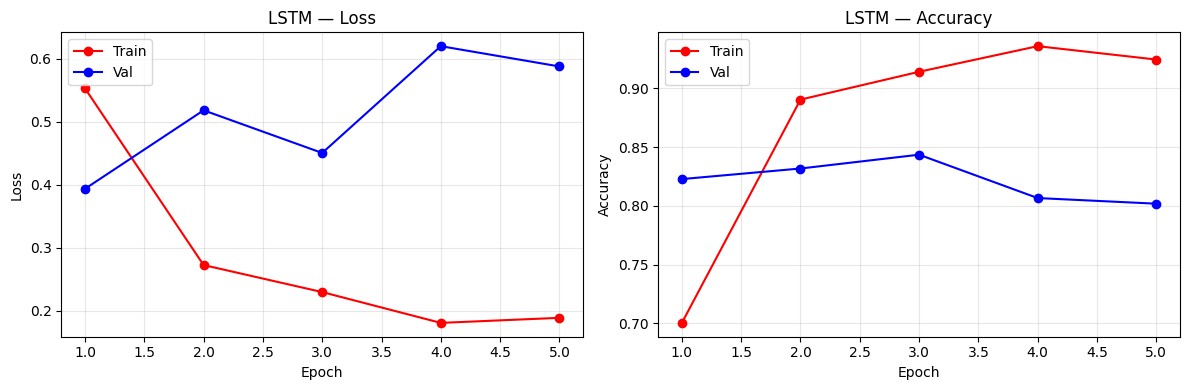

 LSTM Test Accuracy: 0.8019


In [4]:
# --- Train All Models ---
results = {}
for name, layers_fn in models.items():
    print(f"\n{'='*50}\n Training: {name}\n{'='*50}")
    model = tf.keras.Sequential(
        [tf.keras.layers.Embedding(VOCAB_SIZE, EMBED_DIM)]
        + layers_fn()
        + [tf.keras.layers.Dense(1, activation='sigmoid')]
    )
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH,
              validation_data=(X_test, y_test),
              callbacks=[LivePlot(name)], verbose=0)
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[name] = acc
    print(f" {name} Test Accuracy: {acc:.4f}")

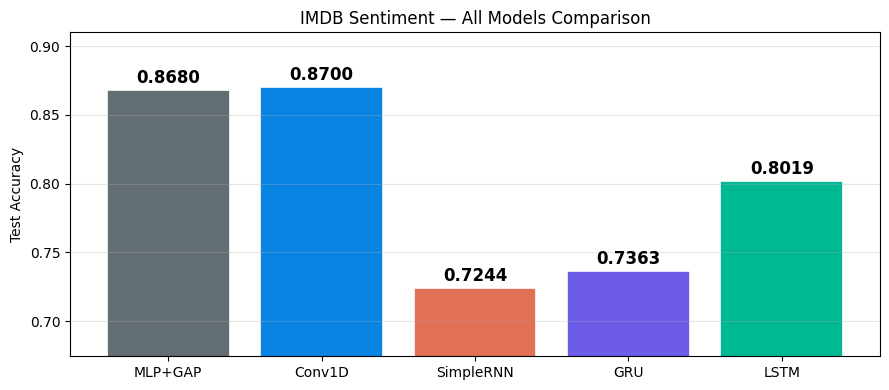

In [5]:
# --- Final Comparison ---
clear_output(wait=True)
fig, ax = plt.subplots(figsize=(9, 4))
names = list(results.keys())
accs = list(results.values())
colors = ['#636e72', '#0984e3', '#e17055', '#6c5ce7', '#00b894']
bars = ax.bar(names, accs, color=colors, edgecolor='white', linewidth=1.2)
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.4f}',
            ha='center', fontweight='bold', fontsize=12)
ax.set(title='IMDB Sentiment — All Models Comparison', ylabel='Test Accuracy')
ax.set_ylim(min(accs) - 0.05, max(accs) + 0.04)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); display(fig); plt.close(fig)